# NB4 (FIXED) — Volatility-Conditioned RL
**Per-market cells · Google-Drive checkpointing · resume-after-disconnect · Q1 figures**

Fixes vs the old run:
- `episodes = 300` (was silently 10) and `eps_decay = 0.99` so exploration actually decays → agents really train.
- The stray *recovery* cell that overwrote `CFG` is gone.
- Every market has its **own cell** (run any one independently).
- All checkpoints/outputs are written to **Google Drive**, and results are saved **after every (agent, state, seed)** — if the runtime disconnects, just re-run the same cell and it continues from where it stopped.
- DSE is loaded from a Drive folder named **`dsex`** (path auto-detected).

**Run order:** run Cell 0 (setup) once, then the market cells (in any order / any time), then the final two cells to combine everything and draw the figures.

In [1]:
# ==========================================================
# CELL 0 — SETUP  (run once per session)
# ==========================================================
!pip -q install yfinance 2>/dev/null

import os, math, random, warnings, glob, time
import numpy as np, pandas as pd
from scipy import stats
warnings.filterwarnings("ignore")

# ---- Google Drive: persistent storage so a disconnect never loses progress ----
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = "/content/drive/MyDrive"
except Exception as e:
    print("Drive mount skipped:", e); DRIVE = "."

OUTPUT_DIR = os.path.join(DRIVE, "nb4_outputs")
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")   # per-market files live here
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
for d in (OUTPUT_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)

# ---- DSE: folder 'DSE-Stock' in Drive; 3 index files -> use DSEX (broad market) ----
DSE_FOLDER    = os.path.join(DRIVE, "DSE-Stock")
DSE_PREFERRED = "00DSEX.CSV"   # DSEX = broad market index. Change to 00DS30.CSV or 00DSES.CSV if you prefer.
def _find_dse_csv():
    if not os.path.isdir(DSE_FOLDER):
        print("  !! DSE folder not found:", DSE_FOLDER); return None
    files = os.listdir(DSE_FOLDER)
    def pick(name):                       # case-insensitive filename match
        for f in files:
            if f.lower() == name.lower(): return os.path.join(DSE_FOLDER, f)
        return None
    for cand in [DSE_PREFERRED, "00DSEX.CSV", "00DS30.CSV", "00DSES.CSV"]:
        p = pick(cand)
        if p: return p
    csvs = sorted(f for f in files if f.lower().endswith(".csv"))
    return os.path.join(DSE_FOLDER, csvs[0]) if csvs else None
DSE_CSV = _find_dse_csv()
print("DSE folder:", DSE_FOLDER, "| using:", DSE_CSV)

MARKETS = {
  "SP500":{"ticker":"^GSPC","group":"Developed"},  "NASDAQ":{"ticker":"^IXIC","group":"Developed"},
  "FTSE100":{"ticker":"^FTSE","group":"Developed"},"Nikkei":{"ticker":"^N225","group":"Developed"},
  "DAX":{"ticker":"^GDAXI","group":"Developed"},   "ASX200":{"ticker":"^AXJO","group":"Developed"},
  "Nifty50":{"ticker":"^NSEI","group":"Emerging"}, "Bovespa":{"ticker":"^BVSP","group":"Emerging"},
  "KOSPI":{"ticker":"^KS11","group":"Emerging"},   "MexIPC":{"ticker":"^MXX","group":"Emerging"},
  "DSE":{"csv":DSE_CSV,"group":"Frontier"},        "Vietnam":{"ticker":"VNM","group":"Frontier"},
  "BTC":{"ticker":"BTC-USD","group":"Crypto"},     "ETH":{"ticker":"ETH-USD","group":"Crypto"},
}

CFG = {
  "start":"2010-01-01","end":None,"min_obs":1200,
  "train_frac":0.70,"val_frac":0.15,"seq_len":20,"vol_window":5,
  "run_lstm_vol":True,
  "agents":["Q-Learning","SARSA","DQN","PPO"],
  "states":["Baseline","+RetFore","+VolFore"],
  "seeds":[0,1,2,3,4],
  "episodes":300,                                  # FIXED (was 10)
  "initial_capital":10000.0,"transaction_cost":0.001,"slippage":0.0005,
  "gamma":0.95,"alpha":0.10,
  "eps_start":1.0,"eps_min":0.05,"eps_decay":0.99, # FIXED so it decays over 300 eps
  "max_leverage":1.0,"vol_target_annual":0.15,"block":60,
}

def set_seed(s):
    random.seed(s); np.random.seed(s)
    try:
        import torch; torch.manual_seed(s)
    except Exception: pass

import torch, torch.nn as nn
from collections import deque
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
DEV = DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV, "| episodes:", CFG["episodes"], "| eps_decay:", CFG["eps_decay"])

# ---------------- features + forecasts ----------------
FEATS    = ["log_ret","ma_diff","rsi","momentum","volatility","macd","bb_pos"]
RL_FEATS = ["momentum","rsi","ma_diff","volatility"]

def rsi_(s, n=14):
    d = s.diff(); g = d.clip(lower=0).rolling(n).mean(); l = (-d.clip(upper=0)).rolling(n).mean()
    return (100 - 100/(1 + g/l.replace(0,np.nan))).fillna(50.0)

def build_features(px):
    h = CFG["vol_window"]
    df = pd.DataFrame({"close":px})
    df["log_ret"]  = np.log(df["close"]).diff()
    df["ma_diff"]  = (df["close"].rolling(5).mean() - df["close"].rolling(10).mean())/df["close"]
    df["rsi"]      = rsi_(df["close"])
    df["momentum"] = df["close"].pct_change(10)
    df["volatility"]= df["log_ret"].rolling(20).std()
    e12=df["close"].ewm(span=12,adjust=False).mean(); e26=df["close"].ewm(span=26,adjust=False).mean()
    df["macd"]=(e12-e26)/df["close"]
    mb=df["close"].rolling(20).mean(); sd=df["close"].rolling(20).std()
    df["bb_pos"]=(df["close"]-mb)/(2*sd)
    rv = df["log_ret"].rolling(h).std()*math.sqrt(252)
    df["rv"]=rv; df["rv_d"]=rv; df["rv_w"]=rv.rolling(5).mean(); df["rv_m"]=rv.rolling(22).mean()
    df["target_ret"]=df["log_ret"].shift(-1)
    df["target_vol"]=rv.shift(-h)
    return df.dropna()

def diebold_mariano(e1, e2):
    d = e1**2 - e2**2; d = d[np.isfinite(d)]
    dm = d.mean()/np.sqrt(d.var(ddof=1)/len(d))
    return dm, 2*(1-stats.norm.cdf(abs(dm)))

class VolLSTM(nn.Module):
    def __init__(self, F, h=48):
        super().__init__()
        self.rnn = nn.LSTM(F, h, 1, batch_first=True)
        self.head= nn.Sequential(nn.Linear(h,1), nn.Softplus())
    def forward(self, x):
        o,_ = self.rnn(x); return self.head(o[:,-1]).squeeze(-1)

def forecast_market(data, market):
    n=len(data); L=CFG["seq_len"]
    i_tr=int(n*CFG["train_frac"]); i_va=int(n*(CFG["train_frac"]+CFG["val_frac"]))
    tr,te=slice(0,i_tr),slice(i_va,n)
    xr,yr=StandardScaler(),StandardScaler()
    Xr=xr.fit_transform(data[FEATS].iloc[tr]); Yr=yr.fit_transform(data[["target_ret"]].iloc[tr]).ravel()
    lr=LinearRegression().fit(Xr,Yr)
    ret_signal=yr.inverse_transform(lr.predict(xr.transform(data[FEATS])).reshape(-1,1)).ravel()
    har_feats=["rv_d","rv_w","rv_m"]; xh=StandardScaler()
    Xh_tr=xh.fit_transform(data[har_feats].iloc[tr]); yv_tr=data["target_vol"].iloc[tr].values
    har=LinearRegression().fit(Xh_tr,yv_tr)
    har_all=har.predict(xh.transform(data[har_feats]))
    rvvol_baseline=data["rv"].values; y_te=data["target_vol"].iloc[te].values
    vol_signal=har_all; vol_rows=[]
    e_har=y_te-har_all[i_va:]; e_rw=y_te-rvvol_baseline[i_va:]
    dm_s,dm_p=diebold_mariano(e_har,e_rw)
    vol_rows.append(dict(market=market,model="HAR",RMSE=float(np.sqrt(np.nanmean(e_har**2))),DM_vs_RW=float(dm_s),DM_p=float(dm_p)))
    if CFG["run_lstm_vol"]:
        Xv=xh.transform(data[har_feats]); ys=data["target_vol"].values
        xs=np.stack([Xv[i-L:i] for i in range(L,n)])
        Xs=torch.tensor(xs,dtype=torch.float32); Ys=torch.tensor(ys[L:],dtype=torch.float32)
        tr_end,va_end=i_tr-L,i_va-L
        set_seed(42); net=VolLSTM(len(har_feats)).to(DEV)
        opt=torch.optim.Adam(net.parameters(),lr=1e-3); lf=nn.MSELoss()
        dl=torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xs[:tr_end],Ys[:tr_end]),batch_size=128,shuffle=True)
        best,bs,bad=np.inf,None,0
        for _ in range(40):
            net.train()
            for xb,yb in dl:
                opt.zero_grad(); lf(net(xb.to(DEV)),yb.to(DEV)).backward(); opt.step()
            net.eval()
            with torch.no_grad():
                vl=lf(net(Xs[tr_end:va_end].to(DEV)),Ys[tr_end:va_end].to(DEV)).item()
            if vl<best-1e-9: best,bs,bad=vl,{k:v.clone() for k,v in net.state_dict().items()},0
            else:
                bad+=1
                if bad>=6: break
        net.load_state_dict(bs); net.eval()
        with torch.no_grad():
            lstm_all=np.concatenate([np.full(L,np.nan), net(Xs.to(DEV)).cpu().numpy()])
        e_l=y_te-lstm_all[i_va:]
        dm_s2,dm_p2=diebold_mariano(e_l[~np.isnan(e_l)],e_rw[~np.isnan(e_l)])
        vol_rows.append(dict(market=market,model="LSTM-vol",RMSE=float(np.sqrt(np.nanmean(e_l**2))),DM_vs_RW=float(dm_s2),DM_p=float(dm_p2)))
        if vl < np.mean((yv_tr-har.predict(xh.transform(data[har_feats].iloc[tr])))**2):
            vol_signal=np.where(np.isnan(lstm_all),har_all,lstm_all)
    return dict(ret_signal=ret_signal,vol_signal=vol_signal,vol_rows=vol_rows,i_tr=i_tr,i_va=i_va)

# ---------------- trading environment ----------------
EXPOSURES=np.array([0.0,0.5,1.0])
class RiskEnv:
    def __init__(self, df, state_kind, cfg, mu, sd, ret_sig, vol_sig, ret_sd, vol_mu, vol_sd):
        self.px=df["close"].values; self.f=df[RL_FEATS].values
        self.ret=ret_sig; self.vol=vol_sig; self.kind,self.cfg=state_kind,cfg
        self.mu,self.sd=mu,sd; self.ret_sd,self.vol_mu,self.vol_sd=ret_sd,vol_mu,vol_sd
        self.n=len(self.px)
    def reset(self):
        self.t=0; self.cash=self.cfg["initial_capital"]; self.units=0.0; self.exposure=0.0
        self.worth_hist=[self.cash]; return self._state()
    def _state(self):
        s=list((self.f[self.t]-self.mu)/self.sd)
        if self.kind=="+RetFore": s.append(self.ret[self.t]/(self.ret_sd+1e-12))
        elif self.kind=="+VolFore": s.append((self.vol[self.t]-self.vol_mu)/(self.vol_sd+1e-12))
        s.append(self.exposure); return np.array(s,dtype=np.float32)
    def step(self,a):
        target=EXPOSURES[a]*self.cfg["max_leverage"]; p=self.px[self.t]
        worth=self.cash+self.units*p; desired=target*worth/p; du=desired-self.units
        cost=abs(du)*p*(self.cfg["transaction_cost"]+self.cfg["slippage"])
        self.cash-=du*p+cost; self.units=desired; self.exposure=target; self.t+=1
        done=self.t>=self.n-1; w=self.cash+self.units*self.px[self.t]
        r=w-self.worth_hist[-1]; self.worth_hist.append(w); return self._state(),r,done
    @property
    def state_dim(self):
        return len(RL_FEATS)+(0 if self.kind=="Baseline" else 1)+1

def perf(worth, periods=252):
    w=np.asarray(worth,float); ret=np.diff(w)/w[:-1]; ann=math.sqrt(periods)
    sharpe=ret.mean()/(ret.std()+1e-12)*ann
    dsd=ret[ret<0].std() if (ret<0).any() else 1e-12
    sortino=ret.mean()/(dsd+1e-12)*ann
    peak=np.maximum.accumulate(w); mdd=((w-peak)/peak).min()
    yrs=len(w)/periods; cagr=(w[-1]/w[0])**(1/yrs)-1; calmar=cagr/(abs(mdd)+1e-12)
    return dict(NetWorth=float(w[-1]),Sharpe=float(sharpe),Sortino=float(sortino),
                MaxDD=float(mdd),CAGR=float(cagr),Calmar=float(calmar))

def buy_hold(df,cfg):
    sh=cfg["initial_capital"]/(df["close"].iloc[0]*(1+cfg["transaction_cost"]+cfg["slippage"]))
    return (sh*df["close"]).values

# ---------------- RL agents ----------------
class Disc:
    def __init__(self, kind):
        self.edges=[np.array([-1.,0.,1.]),np.array([-.5,.5]),np.array([-1.,0.,1.]),np.array([-.5,.5])]
        if kind!="Baseline": self.edges.append(np.array([-.5,.5]))
        self.dims=[len(e)+1 for e in self.edges]+[3]
    def __call__(self,s):
        idx=[int(np.digitize(s[i],e)) for i,e in enumerate(self.edges)]
        idx.append(int(np.clip(round(s[-1]*2),0,2))); return tuple(idx)

def train_tabular(env,cfg,seed,on_policy):
    set_seed(seed); disc=Disc(env.kind); Q=np.zeros(tuple(disc.dims)+(3,)); eps=cfg["eps_start"]
    for _ in range(cfg["episodes"]):
        s=disc(env.reset()); a=np.random.randint(3) if np.random.rand()<eps else int(Q[s].argmax()); done=False
        while not done:
            s2r,r,done=env.step(a); s2=disc(s2r)
            a2=np.random.randint(3) if np.random.rand()<eps else int(Q[s2].argmax())
            tn=Q[s2][a2] if on_policy else Q[s2].max()
            Q[s][a]+=cfg["alpha"]*(r+cfg["gamma"]*tn*(not done)-Q[s][a]); s,a=s2,a2
        eps=max(cfg["eps_min"],eps*cfg["eps_decay"])
    return lambda st:int(Q[disc(st)].argmax())

class MLP(nn.Module):
    def __init__(self,di,do):
        super().__init__(); self.f=nn.Sequential(nn.Linear(di,64),nn.ReLU(),nn.Linear(64,64),nn.ReLU(),nn.Linear(64,do))
    def forward(self,x): return self.f(x)

def train_dqn(env,cfg,seed):
    set_seed(seed); q,qt=MLP(env.state_dim,3).to(DEVICE),MLP(env.state_dim,3).to(DEVICE)
    qt.load_state_dict(q.state_dict()); opt=torch.optim.Adam(q.parameters(),lr=1e-3)
    buf,eps,step,sc=deque(maxlen=50_000),cfg["eps_start"],0,cfg["initial_capital"]
    for _ in range(cfg["episodes"]):
        s=env.reset(); done=False
        while not done:
            a=np.random.randint(3) if np.random.rand()<eps else int(q(torch.tensor(s[None]).to(DEVICE)).argmax())
            s2,r,done=env.step(a); buf.append((s,a,r/sc,s2,float(done))); s=s2; step+=1
            if len(buf)>=1000 and step%2==0:
                bs,ba,br,bs2,bd=map(np.array,zip(*random.sample(buf,64)))
                bs=torch.tensor(bs,dtype=torch.float32).to(DEVICE); bs2=torch.tensor(bs2,dtype=torch.float32).to(DEVICE)
                ba=torch.tensor(ba).long().to(DEVICE); br=torch.tensor(br,dtype=torch.float32).to(DEVICE); bd=torch.tensor(bd,dtype=torch.float32).to(DEVICE)
                with torch.no_grad(): tgt=br+cfg["gamma"]*qt(bs2).max(1).values*(1-bd)
                loss=nn.functional.smooth_l1_loss(q(bs).gather(1,ba[:,None]).squeeze(1),tgt)
                opt.zero_grad(); loss.backward(); opt.step()
            if step%500==0: qt.load_state_dict(q.state_dict())
        eps=max(cfg["eps_min"],eps*cfg["eps_decay"])
    return lambda st:int(q(torch.tensor(st[None]).to(DEVICE)).argmax())

class AC(nn.Module):
    def __init__(self,di):
        super().__init__(); self.b=nn.Sequential(nn.Linear(di,64),nn.Tanh(),nn.Linear(64,64),nn.Tanh())
        self.pi=nn.Linear(64,3); self.v=nn.Linear(64,1)
    def forward(self,x):
        h=self.b(x); return torch.distributions.Categorical(logits=self.pi(h)), self.v(h).squeeze(-1)

def train_ppo(env,cfg,seed,clip=0.2,lam=0.95,epochs=4):
    set_seed(seed); ac=AC(env.state_dim).to(DEVICE); opt=torch.optim.Adam(ac.parameters(),lr=3e-4); sc=cfg["initial_capital"]
    for _ in range(cfg["episodes"]):
        S,A,R,LP,V=[],[],[],[],[]; s=env.reset(); done=False
        while not done:
            st=torch.tensor(s[None]).to(DEVICE)
            with torch.no_grad(): dist,v=ac(st); a=dist.sample()
            s2,r,done=env.step(int(a))
            S.append(s); A.append(int(a)); R.append(r/sc); LP.append(float(dist.log_prob(a))); V.append(float(v)); s=s2
        adv,g=np.zeros(len(R)),0.0
        for t in reversed(range(len(R))):
            nv=V[t+1] if t+1<len(R) else 0.0
            g=(R[t]+cfg["gamma"]*nv-V[t])+cfg["gamma"]*lam*g; adv[t]=g
        ret=adv+np.array(V); adv=(adv-adv.mean())/(adv.std()+1e-8)
        S=torch.tensor(np.array(S),dtype=torch.float32).to(DEVICE); A=torch.tensor(A).long().to(DEVICE)
        LP=torch.tensor(LP,dtype=torch.float32).to(DEVICE); AD=torch.tensor(adv,dtype=torch.float32).to(DEVICE); RT=torch.tensor(ret,dtype=torch.float32).to(DEVICE)
        for _ in range(epochs):
            dist,v=ac(S); ratio=torch.exp(dist.log_prob(A)-LP)
            pl=-torch.min(ratio*AD,torch.clamp(ratio,1-clip,1+clip)*AD).mean()
            loss=pl+0.5*nn.functional.mse_loss(v,RT)-0.01*dist.entropy().mean()
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(ac.parameters(),0.5); opt.step()
    return lambda st:int(ac(torch.tensor(st[None]).to(DEVICE))[0].probs.argmax())

TRAINERS={"Q-Learning":lambda e,c,s:train_tabular(e,c,s,False),
          "SARSA":lambda e,c,s:train_tabular(e,c,s,True),
          "DQN":train_dqn,"PPO":train_ppo}

def rollout(policy,env):
    s=env.reset(); done=False
    while not done: s,_,done=env.step(policy(s))
    return np.array(env.worth_hist)

# ---------------- data loader (cached to Drive) ----------------
def load_price(market):
    cache=os.path.join(CKPT_DIR,f"{market}_price.csv")
    if os.path.exists(cache):
        return pd.read_csv(cache,parse_dates=["Date"]).set_index("Date")["Close"].astype(float).dropna()
    spec=MARKETS[market]
    if spec.get("csv"):
        df=pd.read_csv(spec["csv"])
        df.columns=[str(c).strip().lstrip("<").rstrip(">").strip() for c in df.columns]  # handle <DATE> style
        low={c.lower():c for c in df.columns}
        dcol=next((low[k] for k in ["date","dates","datetime","time"] if k in low),None)
        ccol=next((low[k] for k in ["close","adj close","closep","close price","price","value","index","ltp","last"] if k in low),None)
        if dcol is None or ccol is None:
            raise ValueError(f"{market}: need Date + Close-like columns, got {list(df.columns)}")
        df[dcol]=pd.to_datetime(df[dcol],errors="coerce")
        df[ccol]=pd.to_numeric(df[ccol].astype(str).str.replace(",",""),errors="coerce")  # strip thousands commas
        s=df.dropna(subset=[dcol,ccol]).set_index(dcol)[ccol].astype(float).sort_index()
        print(f"  [{market}] loaded {len(s)} rows from CSV: {os.path.basename(spec['csv'])}  ({s.index.min().date()} -> {s.index.max().date()})")
    else:
        import yfinance as yf
        raw=yf.download(spec["ticker"],start=CFG["start"],end=CFG["end"],auto_adjust=True,progress=False)
        px=raw["Close"]; px=px.iloc[:,0] if isinstance(px,pd.DataFrame) else px; s=px.dropna()
    s.rename("Close").rename_axis("Date").to_frame().to_csv(cache)
    return s

def get_forecast(market, data):
    cache=os.path.join(CKPT_DIR,f"{market}_signals.npz")
    if os.path.exists(cache):
        z=np.load(cache,allow_pickle=True)
        return dict(ret_signal=z["ret_signal"],vol_signal=z["vol_signal"],i_tr=int(z["i_tr"]),i_va=int(z["i_va"]))
    fc=forecast_market(data,market)
    np.savez(cache,ret_signal=fc["ret_signal"],vol_signal=fc["vol_signal"],i_tr=fc["i_tr"],i_va=fc["i_va"])
    pd.DataFrame(fc["vol_rows"]).to_csv(os.path.join(CKPT_DIR,f"{market}_vol.csv"),index=False)
    return fc

# ---------------- the per-market runner (checkpointed + resumable) ----------------
def run_market(market):
    t0=time.time(); rl_path=os.path.join(CKPT_DIR,f"{market}_rl.csv")
    rows=[]; done=set()
    if os.path.exists(rl_path):
        prev=pd.read_csv(rl_path); rows=prev.to_dict("records")
        for r in rows: done.add((r["agent"],r["state"],int(r["seed"])))
        print(f"[{market}] resume: {len(rows)} rows already saved")
    total=1+len(CFG["agents"])*len(CFG["states"])*len(CFG["seeds"])
    if len(done)>=total:
        print(f"[{market}] already COMPLETE ({len(rows)} rows) - skipping."); return
    px=load_price(market)
    if len(px)<CFG["min_obs"]:
        print(f"[{market}] SKIP: only {len(px)} obs (<{CFG['min_obs']})"); return
    data=build_features(px); fc=get_forecast(market,data); i_va=fc["i_va"]
    tr,te=data.iloc[:i_va],data.iloc[i_va:]
    mu=tr[RL_FEATS].values.mean(0); sd=tr[RL_FEATS].values.std(0)+1e-12
    ret_sd=np.nanstd(fc["ret_signal"][:i_va]); vol_mu=np.nanmean(fc["vol_signal"][:i_va]); vol_sd=np.nanstd(fc["vol_signal"][:i_va])
    ret_te,vol_te=fc["ret_signal"][i_va:],fc["vol_signal"][i_va:]; ret_tr,vol_tr=fc["ret_signal"][:i_va],fc["vol_signal"][:i_va]
    def save(): pd.DataFrame(rows).to_csv(rl_path,index=False)   # write after every result
    if ("BuyHold","-",-1) not in done:
        rows.append(dict(market=market,group=MARKETS[market]["group"],agent="BuyHold",state="-",seed=-1,**perf(buy_hold(te,CFG))))
        done.add(("BuyHold","-",-1)); save()
    for agent in CFG["agents"]:
        for kind in CFG["states"]:
            for seed in CFG["seeds"]:
                if (agent,kind,seed) in done: continue
                env_tr=RiskEnv(tr,kind,CFG,mu,sd,ret_tr,vol_tr,ret_sd,vol_mu,vol_sd)
                env_te=RiskEnv(te,kind,CFG,mu,sd,ret_te,vol_te,ret_sd,vol_mu,vol_sd)
                m=perf(rollout(TRAINERS[agent](env_tr,CFG,seed),env_te))
                rows.append(dict(market=market,group=MARKETS[market]["group"],agent=agent,state=kind,seed=seed,**m))
                done.add((agent,kind,seed)); save()
                print(f"  [{market}] {agent:10s} {kind:9s} seed{seed} -> Sharpe {m['Sharpe']:+.3f}  MaxDD {m['MaxDD']:+.3f}")
    print(f"[{market}] DONE in {time.time()-t0:.0f}s | {len(rows)} rows -> {rl_path}")

print("Setup complete. Now run the per-market cells below (any order, resumable).")

Mounted at /content/drive
DSE folder: /content/drive/MyDrive/DSE-Stock | using: /content/drive/MyDrive/DSE-Stock/00DSEX.csv
device: cpu | episodes: 300 | eps_decay: 0.99
Setup complete. Now run the per-market cells below (any order, resumable).


### Cell 1 — SP500

In [ ]:
# ==== SP500 ====  (re-run anytime; it resumes from the last saved seed)
run_market("SP500")

[SP500] resume: 5 rows already saved
  [SP500] Q-Learning Baseline  seed4 -> Sharpe -0.329  MaxDD -0.109
  [SP500] Q-Learning +RetFore  seed0 -> Sharpe -0.352  MaxDD -0.210
  [SP500] Q-Learning +RetFore  seed1 -> Sharpe -0.611  MaxDD -0.236
  [SP500] Q-Learning +RetFore  seed2 -> Sharpe -1.112  MaxDD -0.223
  [SP500] Q-Learning +RetFore  seed3 -> Sharpe -0.465  MaxDD -0.176
  [SP500] Q-Learning +RetFore  seed4 -> Sharpe -0.653  MaxDD -0.248
  [SP500] Q-Learning +VolFore  seed0 -> Sharpe -0.102  MaxDD -0.109
  [SP500] Q-Learning +VolFore  seed1 -> Sharpe -0.011  MaxDD -0.102
  [SP500] Q-Learning +VolFore  seed2 -> Sharpe -0.842  MaxDD -0.185
  [SP500] Q-Learning +VolFore  seed3 -> Sharpe +0.125  MaxDD -0.087
  [SP500] Q-Learning +VolFore  seed4 -> Sharpe -0.003  MaxDD -0.103
  [SP500] SARSA      Baseline  seed0 -> Sharpe -0.880  MaxDD -0.207
  [SP500] SARSA      Baseline  seed1 -> Sharpe +0.219  MaxDD -0.093
  [SP500] SARSA      Baseline  seed2 -> Sharpe -1.516  MaxDD -0.178
  [SP500] S

### Cell 2 — NASDAQ

In [3]:
# ==== NASDAQ ====  (re-run anytime; it resumes from the last saved seed)
run_market("NASDAQ")

[NASDAQ] resume: 37 rows already saved
  [NASDAQ] DQN        +RetFore  seed1 -> Sharpe +1.542  MaxDD -0.125
  [NASDAQ] DQN        +RetFore  seed2 -> Sharpe -0.251  MaxDD -0.138
  [NASDAQ] DQN        +RetFore  seed3 -> Sharpe +0.750  MaxDD -0.154
  [NASDAQ] DQN        +RetFore  seed4 -> Sharpe -0.593  MaxDD -0.180
  [NASDAQ] DQN        +VolFore  seed0 -> Sharpe +0.540  MaxDD -0.148
  [NASDAQ] DQN        +VolFore  seed1 -> Sharpe +0.894  MaxDD -0.234
  [NASDAQ] DQN        +VolFore  seed2 -> Sharpe +0.780  MaxDD -0.249
  [NASDAQ] DQN        +VolFore  seed3 -> Sharpe +0.891  MaxDD -0.231
  [NASDAQ] DQN        +VolFore  seed4 -> Sharpe +0.338  MaxDD -0.270
  [NASDAQ] PPO        Baseline  seed0 -> Sharpe +1.164  MaxDD -0.211
  [NASDAQ] PPO        Baseline  seed1 -> Sharpe +1.131  MaxDD -0.243
  [NASDAQ] PPO        Baseline  seed2 -> Sharpe +0.772  MaxDD -0.199
  [NASDAQ] PPO        Baseline  seed3 -> Sharpe +1.138  MaxDD -0.243
  [NASDAQ] PPO        Baseline  seed4 -> Sharpe +1.011  MaxDD -0

### Cell 3 — FTSE100

In [ ]:
# ==== FTSE100 ====  (re-run anytime; it resumes from the last saved seed)
run_market("FTSE100")

  [FTSE100] Q-Learning Baseline  seed0 -> Sharpe -0.477  MaxDD -0.022
  [FTSE100] Q-Learning Baseline  seed1 -> Sharpe +0.395  MaxDD -0.004
  [FTSE100] Q-Learning Baseline  seed2 -> Sharpe -0.846  MaxDD -0.077
  [FTSE100] Q-Learning Baseline  seed3 -> Sharpe -0.229  MaxDD -0.019
  [FTSE100] Q-Learning Baseline  seed4 -> Sharpe -0.209  MaxDD -0.007
  [FTSE100] Q-Learning +RetFore  seed0 -> Sharpe -0.474  MaxDD -0.046
  [FTSE100] Q-Learning +RetFore  seed1 -> Sharpe -0.615  MaxDD -0.020
  [FTSE100] Q-Learning +RetFore  seed2 -> Sharpe -0.595  MaxDD -0.015
  [FTSE100] Q-Learning +RetFore  seed3 -> Sharpe -0.851  MaxDD -0.029
  [FTSE100] Q-Learning +RetFore  seed4 -> Sharpe -0.550  MaxDD -0.020
  [FTSE100] Q-Learning +VolFore  seed0 -> Sharpe +0.731  MaxDD -0.016
  [FTSE100] Q-Learning +VolFore  seed1 -> Sharpe +0.365  MaxDD -0.023
  [FTSE100] Q-Learning +VolFore  seed2 -> Sharpe +0.340  MaxDD -0.026
  [FTSE100] Q-Learning +VolFore  seed3 -> Sharpe +0.898  MaxDD -0.024
  [FTSE100] Q-Learni

### Cell 4 — Nikkei

In [ ]:
# ==== Nikkei ====  (re-run anytime; it resumes from the last saved seed)
run_market("Nikkei")

[Nikkei] resume: 34 rows already saved
  [Nikkei] DQN        Baseline  seed3 -> Sharpe +0.754  MaxDD -0.286
  [Nikkei] DQN        Baseline  seed4 -> Sharpe -0.287  MaxDD -0.246
  [Nikkei] DQN        +RetFore  seed0 -> Sharpe -0.227  MaxDD -0.340
  [Nikkei] DQN        +RetFore  seed1 -> Sharpe +0.355  MaxDD -0.198
  [Nikkei] DQN        +RetFore  seed2 -> Sharpe -0.801  MaxDD -0.380
  [Nikkei] DQN        +RetFore  seed3 -> Sharpe +0.318  MaxDD -0.105
  [Nikkei] DQN        +RetFore  seed4 -> Sharpe +0.871  MaxDD -0.229
  [Nikkei] DQN        +VolFore  seed0 -> Sharpe -0.270  MaxDD -0.321
  [Nikkei] DQN        +VolFore  seed1 -> Sharpe +0.358  MaxDD -0.308
  [Nikkei] DQN        +VolFore  seed2 -> Sharpe +0.834  MaxDD -0.151
  [Nikkei] DQN        +VolFore  seed3 -> Sharpe -0.081  MaxDD -0.203
  [Nikkei] DQN        +VolFore  seed4 -> Sharpe +0.124  MaxDD -0.237
  [Nikkei] PPO        Baseline  seed0 -> Sharpe +0.953  MaxDD -0.134
  [Nikkei] PPO        Baseline  seed1 -> Sharpe +0.961  MaxDD -0

### Cell 5 — DAX

In [ ]:
# ==== DAX ====  (re-run anytime; it resumes from the last saved seed)
run_market("DAX")

[DAX] resume: 46 rows already saved
  [DAX] PPO        Baseline  seed0 -> Sharpe +1.219  MaxDD -0.153
  [DAX] PPO        Baseline  seed1 -> Sharpe +1.077  MaxDD -0.083
  [DAX] PPO        Baseline  seed2 -> Sharpe +1.077  MaxDD -0.083
  [DAX] PPO        Baseline  seed3 -> Sharpe +1.098  MaxDD -0.159
  [DAX] PPO        Baseline  seed4 -> Sharpe +1.077  MaxDD -0.083
  [DAX] PPO        +RetFore  seed0 -> Sharpe +1.190  MaxDD -0.160
  [DAX] PPO        +RetFore  seed1 -> Sharpe +1.085  MaxDD -0.160
  [DAX] PPO        +RetFore  seed2 -> Sharpe +0.927  MaxDD -0.159
  [DAX] PPO        +RetFore  seed3 -> Sharpe +0.913  MaxDD -0.193
  [DAX] PPO        +RetFore  seed4 -> Sharpe +1.085  MaxDD -0.160
  [DAX] PPO        +VolFore  seed0 -> Sharpe +1.134  MaxDD -0.160
  [DAX] PPO        +VolFore  seed1 -> Sharpe +0.737  MaxDD -0.160
  [DAX] PPO        +VolFore  seed2 -> Sharpe +0.943  MaxDD -0.159
  [DAX] PPO        +VolFore  seed3 -> Sharpe +1.019  MaxDD -0.160
  [DAX] PPO        +VolFore  seed4 -> Sh

### Cell 6 — ASX200

In [ ]:
# ==== ASX200 ====  (re-run anytime; it resumes from the last saved seed)
run_market("ASX200")

  [ASX200] Q-Learning Baseline  seed0 -> Sharpe +0.258  MaxDD -0.014
  [ASX200] Q-Learning Baseline  seed1 -> Sharpe -0.281  MaxDD -0.044
  [ASX200] Q-Learning Baseline  seed2 -> Sharpe +0.228  MaxDD -0.025
  [ASX200] Q-Learning Baseline  seed3 -> Sharpe +0.603  MaxDD -0.014
  [ASX200] Q-Learning Baseline  seed4 -> Sharpe +0.225  MaxDD -0.022
  [ASX200] Q-Learning +RetFore  seed0 -> Sharpe -0.542  MaxDD -0.069
  [ASX200] Q-Learning +RetFore  seed1 -> Sharpe -1.402  MaxDD -0.119
  [ASX200] Q-Learning +RetFore  seed2 -> Sharpe -0.773  MaxDD -0.074
  [ASX200] Q-Learning +RetFore  seed3 -> Sharpe -0.389  MaxDD -0.053
  [ASX200] Q-Learning +RetFore  seed4 -> Sharpe -0.258  MaxDD -0.068
  [ASX200] Q-Learning +VolFore  seed0 -> Sharpe +0.317  MaxDD -0.028
  [ASX200] Q-Learning +VolFore  seed1 -> Sharpe +0.073  MaxDD -0.052
  [ASX200] Q-Learning +VolFore  seed2 -> Sharpe +0.718  MaxDD -0.018
  [ASX200] Q-Learning +VolFore  seed3 -> Sharpe +0.588  MaxDD -0.029
  [ASX200] Q-Learning +VolFore  se

### Cell 7 — Nifty50

In [ ]:
# ==== Nifty50 ====  (re-run anytime; it resumes from the last saved seed)
run_market("Nifty50")

[Nifty50] resume: 54 rows already saved
  [Nifty50] PPO        +RetFore  seed3 -> Sharpe +0.336  MaxDD -0.158
  [Nifty50] PPO        +RetFore  seed4 -> Sharpe +0.336  MaxDD -0.158
  [Nifty50] PPO        +VolFore  seed0 -> Sharpe +0.328  MaxDD -0.082
  [Nifty50] PPO        +VolFore  seed1 -> Sharpe +0.294  MaxDD -0.158
  [Nifty50] PPO        +VolFore  seed2 -> Sharpe +0.328  MaxDD -0.082
  [Nifty50] PPO        +VolFore  seed3 -> Sharpe +0.336  MaxDD -0.158
  [Nifty50] PPO        +VolFore  seed4 -> Sharpe +0.295  MaxDD -0.158
[Nifty50] DONE in 3849s | 61 rows -> /content/drive/MyDrive/nb4_outputs/checkpoints/Nifty50_rl.csv


### Cell 8 — Bovespa

In [ ]:
# ==== Bovespa ====  (re-run anytime; it resumes from the last saved seed)
run_market("Bovespa")

[Bovespa] resume: 15 rows already saved
  [Bovespa] Q-Learning +VolFore  seed4 -> Sharpe -0.696  MaxDD -0.116
  [Bovespa] SARSA      Baseline  seed0 -> Sharpe -3.193  MaxDD -0.295
  [Bovespa] SARSA      Baseline  seed1 -> Sharpe -1.122  MaxDD -0.106
  [Bovespa] SARSA      Baseline  seed2 -> Sharpe -0.678  MaxDD -0.069
  [Bovespa] SARSA      Baseline  seed3 -> Sharpe -0.227  MaxDD -0.032
  [Bovespa] SARSA      Baseline  seed4 -> Sharpe -1.538  MaxDD -0.159
  [Bovespa] SARSA      +RetFore  seed0 -> Sharpe -0.370  MaxDD -0.125
  [Bovespa] SARSA      +RetFore  seed1 -> Sharpe -0.109  MaxDD -0.086
  [Bovespa] SARSA      +RetFore  seed2 -> Sharpe -1.342  MaxDD -0.231
  [Bovespa] SARSA      +RetFore  seed3 -> Sharpe -0.432  MaxDD -0.099
  [Bovespa] SARSA      +RetFore  seed4 -> Sharpe -1.265  MaxDD -0.201
  [Bovespa] SARSA      +VolFore  seed0 -> Sharpe -0.613  MaxDD -0.052
  [Bovespa] SARSA      +VolFore  seed1 -> Sharpe -0.963  MaxDD -0.105
  [Bovespa] SARSA      +VolFore  seed2 -> Sharpe -

### Cell 9 — KOSPI

In [ ]:
# ==== KOSPI ====  (re-run anytime; it resumes from the last saved seed)
run_market("KOSPI")

[KOSPI] resume: 42 rows already saved
  [KOSPI] DQN        +VolFore  seed1 -> Sharpe +0.837  MaxDD -0.355
  [KOSPI] DQN        +VolFore  seed2 -> Sharpe +0.956  MaxDD -0.389
  [KOSPI] DQN        +VolFore  seed3 -> Sharpe +1.032  MaxDD -0.386
  [KOSPI] DQN        +VolFore  seed4 -> Sharpe +0.282  MaxDD -0.386
  [KOSPI] PPO        Baseline  seed0 -> Sharpe +1.186  MaxDD -0.209
  [KOSPI] PPO        Baseline  seed1 -> Sharpe +0.807  MaxDD -0.386
  [KOSPI] PPO        Baseline  seed2 -> Sharpe +0.949  MaxDD -0.386
  [KOSPI] PPO        Baseline  seed3 -> Sharpe +0.647  MaxDD -0.374
  [KOSPI] PPO        Baseline  seed4 -> Sharpe +0.835  MaxDD -0.386
  [KOSPI] PPO        +RetFore  seed0 -> Sharpe +1.207  MaxDD -0.386
  [KOSPI] PPO        +RetFore  seed1 -> Sharpe +1.152  MaxDD -0.386
  [KOSPI] PPO        +RetFore  seed2 -> Sharpe +0.740  MaxDD -0.374
  [KOSPI] PPO        +RetFore  seed3 -> Sharpe +1.208  MaxDD -0.386
  [KOSPI] PPO        +RetFore  seed4 -> Sharpe +1.186  MaxDD -0.209
  [KOSPI] 

### Cell 10 — MexIPC

In [ ]:
# ==== MexIPC ====  (re-run anytime; it resumes from the last saved seed)
run_market("MexIPC")

[MexIPC] resume: 53 rows already saved
  [MexIPC] PPO        +RetFore  seed2 -> Sharpe +0.446  MaxDD -0.081
  [MexIPC] PPO        +RetFore  seed3 -> Sharpe +0.430  MaxDD -0.159
  [MexIPC] PPO        +RetFore  seed4 -> Sharpe +0.299  MaxDD -0.081
  [MexIPC] PPO        +VolFore  seed0 -> Sharpe +0.513  MaxDD -0.108
  [MexIPC] PPO        +VolFore  seed1 -> Sharpe +0.479  MaxDD -0.156
  [MexIPC] PPO        +VolFore  seed2 -> Sharpe +0.624  MaxDD -0.107
  [MexIPC] PPO        +VolFore  seed3 -> Sharpe +0.312  MaxDD -0.155
  [MexIPC] PPO        +VolFore  seed4 -> Sharpe +0.107  MaxDD -0.082
[MexIPC] DONE in 5133s | 61 rows -> /content/drive/MyDrive/nb4_outputs/checkpoints/MexIPC_rl.csv


### Cell 11 — DSE

In [ ]:
# ==== DSE ====  (clears any stale cache from the earlier failed path, then runs fresh)
for _stale in ["DSE_price.csv","DSE_signals.npz","DSE_rl.csv","DSE_vol.csv"]:
    _p=os.path.join(CKPT_DIR,_stale)
    if os.path.exists(_p): os.remove(_p); print("removed stale", _stale)
print("DSE source file:", MARKETS["DSE"]["csv"])
run_market("DSE")

DSE source file: /content/drive/MyDrive/DSE-Stock/00DSEX.csv
  [DSE] loaded 3172 rows from CSV: 00DSEX.csv  (2012-10-01 -> 2026-01-22)
  [DSE] Q-Learning Baseline  seed0 -> Sharpe -0.063  MaxDD -0.083
  [DSE] Q-Learning Baseline  seed1 -> Sharpe +0.371  MaxDD -0.075
  [DSE] Q-Learning Baseline  seed2 -> Sharpe +0.790  MaxDD -0.049
  [DSE] Q-Learning Baseline  seed3 -> Sharpe +0.275  MaxDD -0.089
  [DSE] Q-Learning Baseline  seed4 -> Sharpe -0.962  MaxDD -0.114
  [DSE] Q-Learning +RetFore  seed0 -> Sharpe -0.746  MaxDD -0.138
  [DSE] Q-Learning +RetFore  seed1 -> Sharpe +0.053  MaxDD -0.088
  [DSE] Q-Learning +RetFore  seed2 -> Sharpe -0.252  MaxDD -0.084
  [DSE] Q-Learning +RetFore  seed3 -> Sharpe -0.587  MaxDD -0.132
  [DSE] Q-Learning +RetFore  seed4 -> Sharpe -0.362  MaxDD -0.111
  [DSE] Q-Learning +VolFore  seed0 -> Sharpe -0.481  MaxDD -0.094
  [DSE] Q-Learning +VolFore  seed1 -> Sharpe -0.236  MaxDD -0.101
  [DSE] Q-Learning +VolFore  seed2 -> Sharpe -0.191  MaxDD -0.084
  [DSE]

### Cell 12 — Vietnam

In [ ]:
# ==== Vietnam ====  (re-run anytime; it resumes from the last saved seed)
run_market("Vietnam")

  [Vietnam] Q-Learning Baseline  seed0 -> Sharpe +0.278  MaxDD -0.051
  [Vietnam] Q-Learning Baseline  seed1 -> Sharpe -0.435  MaxDD -0.044
  [Vietnam] Q-Learning Baseline  seed2 -> Sharpe -0.029  MaxDD -0.049
  [Vietnam] Q-Learning Baseline  seed3 -> Sharpe -0.339  MaxDD -0.078
  [Vietnam] Q-Learning Baseline  seed4 -> Sharpe +0.250  MaxDD -0.039
  [Vietnam] Q-Learning +RetFore  seed0 -> Sharpe -0.123  MaxDD -0.061
  [Vietnam] Q-Learning +RetFore  seed1 -> Sharpe -0.513  MaxDD -0.176
  [Vietnam] Q-Learning +RetFore  seed2 -> Sharpe +0.017  MaxDD -0.091
  [Vietnam] Q-Learning +RetFore  seed3 -> Sharpe -0.122  MaxDD -0.085
  [Vietnam] Q-Learning +RetFore  seed4 -> Sharpe -0.255  MaxDD -0.082
  [Vietnam] Q-Learning +VolFore  seed0 -> Sharpe +0.318  MaxDD -0.075
  [Vietnam] Q-Learning +VolFore  seed1 -> Sharpe +0.676  MaxDD -0.065
  [Vietnam] Q-Learning +VolFore  seed2 -> Sharpe +0.504  MaxDD -0.089
  [Vietnam] Q-Learning +VolFore  seed3 -> Sharpe +0.533  MaxDD -0.091
  [Vietnam] Q-Learni

### Cell 13 — BTC

In [2]:
# ==== BTC ====  (re-run anytime; it resumes from the last saved seed)
run_market("BTC")

[BTC] resume: 49 rows already saved
  [BTC] PPO        Baseline  seed3 -> Sharpe +0.232  MaxDD -0.372
  [BTC] PPO        Baseline  seed4 -> Sharpe +0.188  MaxDD -0.381
  [BTC] PPO        +RetFore  seed0 -> Sharpe +0.333  MaxDD -0.282
  [BTC] PPO        +RetFore  seed1 -> Sharpe +0.066  MaxDD -0.390
  [BTC] PPO        +RetFore  seed2 -> Sharpe +0.181  MaxDD -0.396
  [BTC] PPO        +RetFore  seed3 -> Sharpe +0.193  MaxDD -0.312
  [BTC] PPO        +RetFore  seed4 -> Sharpe +0.038  MaxDD -0.396
  [BTC] PPO        +VolFore  seed0 -> Sharpe +0.141  MaxDD -0.365
  [BTC] PPO        +VolFore  seed1 -> Sharpe -0.019  MaxDD -0.429
  [BTC] PPO        +VolFore  seed2 -> Sharpe +0.161  MaxDD -0.353
  [BTC] PPO        +VolFore  seed3 -> Sharpe -0.092  MaxDD -0.450
  [BTC] PPO        +VolFore  seed4 -> Sharpe +0.238  MaxDD -0.256
[BTC] DONE in 8287s | 61 rows -> /content/drive/MyDrive/nb4_outputs/checkpoints/BTC_rl.csv


### Cell 14 — ETH

In [ ]:
# ==== ETH ====  (re-run anytime; it resumes from the last saved seed)
run_market("ETH")

  [ETH] Q-Learning Baseline  seed0 -> Sharpe -0.169  MaxDD -0.181
  [ETH] Q-Learning Baseline  seed1 -> Sharpe +1.080  MaxDD -0.096
  [ETH] Q-Learning Baseline  seed2 -> Sharpe +0.323  MaxDD -0.239
  [ETH] Q-Learning Baseline  seed3 -> Sharpe -0.963  MaxDD -0.430
  [ETH] Q-Learning Baseline  seed4 -> Sharpe +0.016  MaxDD -0.297
  [ETH] Q-Learning +RetFore  seed0 -> Sharpe -0.073  MaxDD -0.346
  [ETH] Q-Learning +RetFore  seed1 -> Sharpe -0.232  MaxDD -0.345
  [ETH] Q-Learning +RetFore  seed2 -> Sharpe -0.555  MaxDD -0.478
  [ETH] Q-Learning +RetFore  seed3 -> Sharpe -0.464  MaxDD -0.490
  [ETH] Q-Learning +RetFore  seed4 -> Sharpe -0.655  MaxDD -0.562
  [ETH] Q-Learning +VolFore  seed0 -> Sharpe +0.610  MaxDD -0.261
  [ETH] Q-Learning +VolFore  seed1 -> Sharpe +0.541  MaxDD -0.338
  [ETH] Q-Learning +VolFore  seed2 -> Sharpe -0.024  MaxDD -0.445
  [ETH] Q-Learning +VolFore  seed3 -> Sharpe +0.479  MaxDD -0.454
  [ETH] Q-Learning +VolFore  seed4 -> Sharpe +0.138  MaxDD -0.354
  [ETH] SA

## Combine all markets + statistical tests
Run after the market cells. Merges every `*_rl.csv` / `*_vol.csv` checkpoint into the two final CSVs and runs the pre-registered tests (with Holm multiple-testing correction).

In [4]:
# ==========================================================
# COMBINE + ANALYSIS
# ==========================================================
import glob
from scipy.stats import wilcoxon

rl_files =sorted(glob.glob(os.path.join(CKPT_DIR,"*_rl.csv")))
vol_files=sorted(glob.glob(os.path.join(CKPT_DIR,"*_vol.csv")))
rl=pd.concat([pd.read_csv(f) for f in rl_files],ignore_index=True)
vf=pd.concat([pd.read_csv(f) for f in vol_files],ignore_index=True)
rl.to_csv(os.path.join(OUTPUT_DIR,"risk_rl_results.csv"),index=False)
vf.to_csv(os.path.join(OUTPUT_DIR,"vol_forecast_results.csv"),index=False)
print("Combined RL:",rl.shape," Vol:",vf.shape," markets:",sorted(rl.market.unique()))

print("\n=== (A) MANIPULATION CHECK: volatility predictability (DM vs RW-vol) ===")
best=vf.loc[vf.groupby("market")["RMSE"].idxmin()]
print(f"Volatility beats RW-vol (DM p<0.05) in {(best.DM_p<0.05).sum()}/{best.market.nunique()} markets")
print(best[["market","model","DM_vs_RW","DM_p"]].round(3).to_string(index=False))

def paired(a,b,metric):
    pv=(rl[rl.agent!="BuyHold"].pivot_table(index=["market","agent","seed"],columns="state",values=metric)
        .dropna(subset=[a,b]))
    d=pv[a]-pv[b]
    try: _,p=wilcoxon(d,alternative="greater")
    except ValueError: p=np.nan
    return d.mean(), p, len(d)

def holm(pvals):
    idx=np.argsort(pvals); adj=np.empty(len(pvals)); run=0
    for r,i in enumerate(idx):
        run=max(run,(len(pvals)-r)*pvals[i]); adj[i]=min(run,1.0)
    return adj

tests=[("+VolFore","Baseline","Sharpe","TREATMENT: vol vs baseline (Sharpe)"),
       ("+RetFore","Baseline","Sharpe","CONTROL:   ret vs baseline (Sharpe)"),
       ("+VolFore","+RetFore","Sharpe","vol vs ret (Sharpe)"),
       ("+VolFore","Baseline","MaxDD","TREATMENT: vol vs baseline (MaxDD, less-bad)"),
       ("+VolFore","Baseline","Sortino","TREATMENT: vol vs baseline (Sortino)")]
res=[paired(a,b,mt) for a,b,mt,_ in tests]
adj=holm([r[1] for r in res])
print("\n=== (B) PAIRED TESTS (Wilcoxon one-sided, Holm-adjusted) ===")
for (a,b,mt,lab),(d,p,n),pa in zip(tests,res,adj):
    flag="  <== sig" if (pa<0.05) else ""
    print(f"{lab:44s} meanD={d:+.4f}  p={p:.4f}  p_holm={pa:.4f} (n={n}){flag}")

print("\n=== By efficiency group: mean dSharpe(+VolFore - Baseline) ===")
pv=(rl[rl.agent!="BuyHold"].pivot_table(index=["market","group","agent","seed"],columns="state",values="Sharpe").reset_index())
pv["dvol"]=pv["+VolFore"]-pv["Baseline"]
print(pv.groupby("group")["dvol"].mean().round(4).to_string())

Combined RL: (854, 11)  Vol: (28, 5)  markets: ['ASX200', 'BTC', 'Bovespa', 'DAX', 'DSE', 'ETH', 'FTSE100', 'KOSPI', 'MexIPC', 'NASDAQ', 'Nifty50', 'Nikkei', 'SP500', 'Vietnam']

=== (A) MANIPULATION CHECK: volatility predictability (DM vs RW-vol) ===
Volatility beats RW-vol (DM p<0.05) in 14/14 markets
 market    model  DM_vs_RW  DM_p
 ASX200      HAR    -4.202 0.000
    BTC LSTM-vol    -2.929 0.003
Bovespa      HAR    -5.098 0.000
    DAX      HAR    -4.679 0.000
    DSE      HAR    -3.643 0.000
    ETH LSTM-vol    -5.736 0.000
FTSE100      HAR    -3.061 0.002
  KOSPI      HAR    -3.838 0.000
 MexIPC LSTM-vol    -6.099 0.000
 NASDAQ      HAR    -2.816 0.005
Nifty50      HAR    -3.457 0.001
 Nikkei      HAR    -2.788 0.005
  SP500      HAR    -2.614 0.009
Vietnam      HAR    -2.337 0.019

=== (B) PAIRED TESTS (Wilcoxon one-sided, Holm-adjusted) ===
TREATMENT: vol vs baseline (Sharpe)          meanD=+0.1208  p=0.0009  p_holm=0.0038 (n=280)  <== sig
CONTROL:   ret vs baseline (Sharpe)  

## Q1-ready figures (6)
Saved to your Drive `nb4_outputs/figures/` at 300 dpi (PNG + PDF).

saved fig1_manipulation_check
saved fig2_sharpe_by_agent_state
saved fig3_delta_sharpe_by_market
saved fig4_delta_by_group
saved fig5_maxdd_by_state
saved fig6_effect_forest


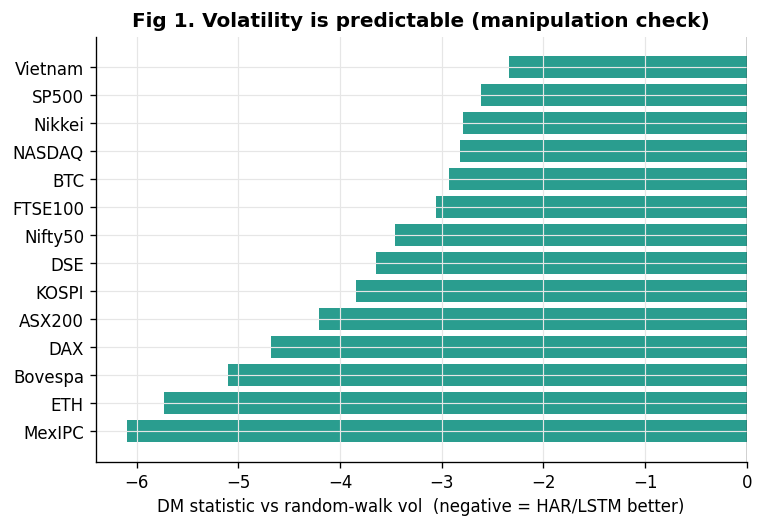

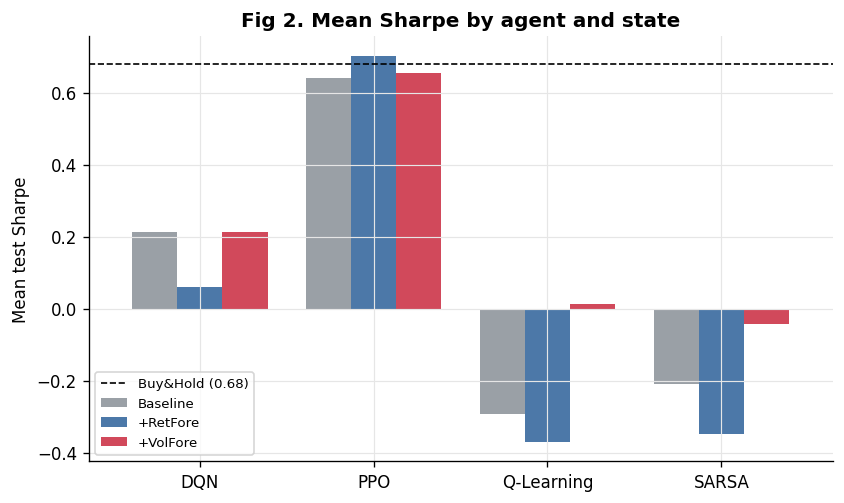

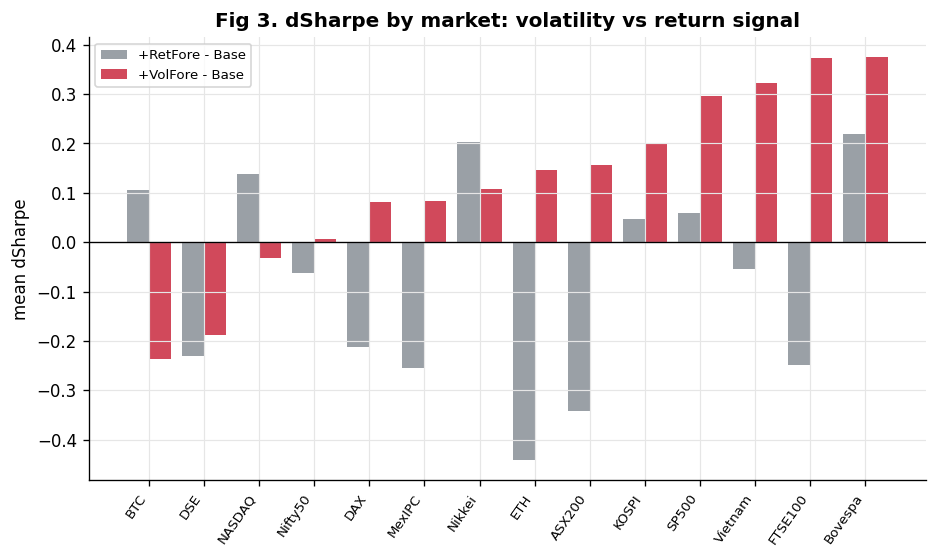

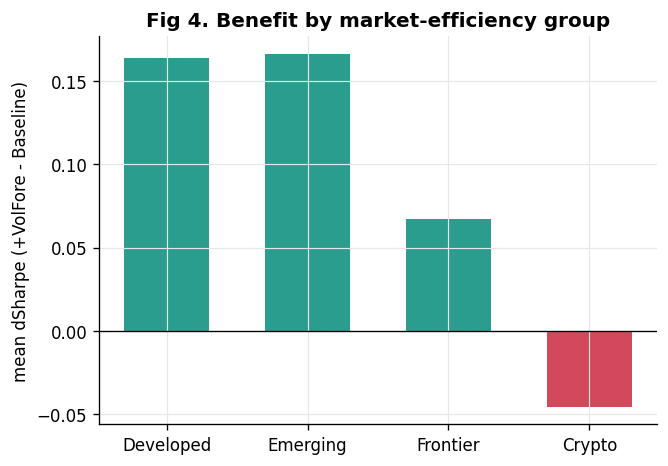

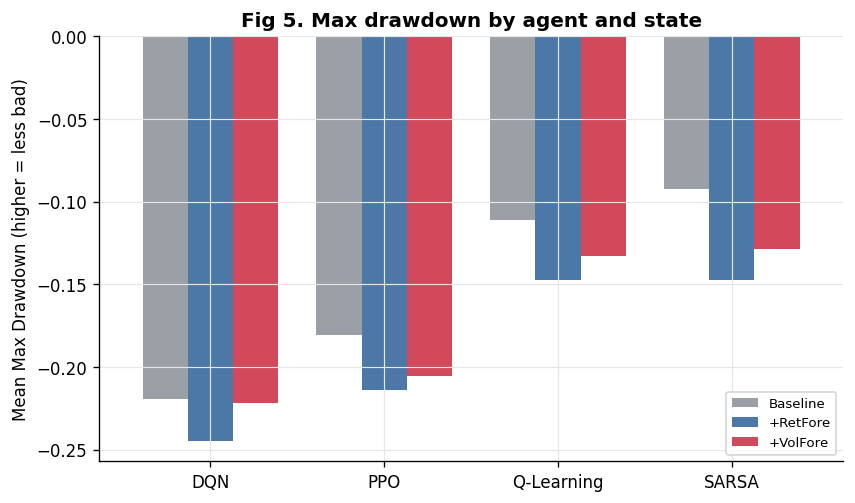

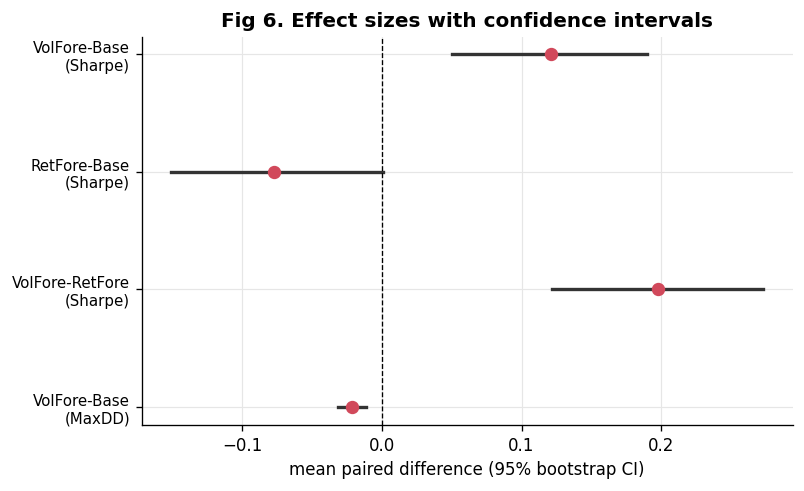


All figures in: /content/drive/MyDrive/nb4_outputs/figures


In [5]:
# ==========================================================
# Q1 FIGURES (saved 300 dpi to Drive)
# ==========================================================
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                     "font.family":"DejaVu Sans","axes.grid":True,"grid.color":"#e6e6e6","grid.linewidth":.7})
GORDER=["Developed","Emerging","Frontier","Crypto"]
C={"Baseline":"#9aa0a6","+RetFore":"#4c78a8","+VolFore":"#d1495b"}
def savefig(fig,name):
    for ext in ("png","pdf"):
        fig.savefig(os.path.join(FIG_DIR,f"{name}.{ext}"),bbox_inches="tight")
    print("saved",name)

sub=rl[rl.agent!="BuyHold"].copy()
best=vf.loc[vf.groupby("market")["RMSE"].idxmin()].sort_values("DM_vs_RW")

# Fig 1 — manipulation check
fig,ax=plt.subplots(figsize=(7,4.6))
ax.barh(best.market,best.DM_vs_RW,color="#2a9d8f")
ax.axvline(0,color="k",lw=.8); ax.set_xlabel("DM statistic vs random-walk vol  (negative = HAR/LSTM better)")
ax.set_title("Fig 1. Volatility is predictable (manipulation check)",fontweight="bold")
savefig(fig,"fig1_manipulation_check")

# Fig 2 — mean Sharpe by agent x state
means=sub.groupby(["agent","state"])["Sharpe"].mean().unstack()[["Baseline","+RetFore","+VolFore"]]
fig,ax=plt.subplots(figsize=(8,4.6)); means.plot(kind="bar",ax=ax,color=[C[c] for c in means.columns],width=.78)
bh=rl[rl.agent=="BuyHold"]["Sharpe"].mean(); ax.axhline(bh,color="k",ls="--",lw=1,label=f"Buy&Hold ({bh:.2f})")
ax.set_ylabel("Mean test Sharpe"); ax.set_xlabel(""); ax.tick_params(axis="x",rotation=0)
ax.set_title("Fig 2. Mean Sharpe by agent and state",fontweight="bold"); ax.legend(fontsize=8)
savefig(fig,"fig2_sharpe_by_agent_state")

# Fig 3 — dSharpe per market
pv=sub.pivot_table(index=["market","agent","seed"],columns="state",values="Sharpe")
dv=(pv["+VolFore"]-pv["Baseline"]).groupby("market").mean().sort_values()
dr=(pv["+RetFore"]-pv["Baseline"]).groupby("market").mean().reindex(dv.index)
x=np.arange(len(dv)); w=.4
fig,ax=plt.subplots(figsize=(9,4.8))
ax.bar(x-w/2,dr.values,w,label="+RetFore - Base",color="#9aa0a6")
ax.bar(x+w/2,dv.values,w,label="+VolFore - Base",color="#d1495b")
ax.axhline(0,color="k",lw=.8); ax.set_xticks(x); ax.set_xticklabels(dv.index,rotation=55,ha="right",fontsize=8)
ax.set_ylabel("mean dSharpe"); ax.set_title("Fig 3. dSharpe by market: volatility vs return signal",fontweight="bold"); ax.legend(fontsize=8)
savefig(fig,"fig3_delta_sharpe_by_market")

# Fig 4 — dSharpe by efficiency group
pvg=sub.pivot_table(index=["market","group","agent","seed"],columns="state",values="Sharpe").reset_index()
pvg["dvol"]=pvg["+VolFore"]-pvg["Baseline"]; g=pvg.groupby("group")["dvol"].mean().reindex(GORDER)
fig,ax=plt.subplots(figsize=(6,4.2))
ax.bar(range(len(g)),g.values,color=["#2a9d8f" if v>0 else "#d1495b" for v in g.values],width=.6)
ax.axhline(0,color="k",lw=.8); ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index)
ax.set_ylabel("mean dSharpe (+VolFore - Baseline)"); ax.set_title("Fig 4. Benefit by market-efficiency group",fontweight="bold")
savefig(fig,"fig4_delta_by_group")

# Fig 5 — MaxDrawdown by state
mdd=sub.groupby(["agent","state"])["MaxDD"].mean().unstack()[["Baseline","+RetFore","+VolFore"]]
fig,ax=plt.subplots(figsize=(8,4.6)); mdd.plot(kind="bar",ax=ax,color=[C[c] for c in mdd.columns],width=.78)
ax.set_ylabel("Mean Max Drawdown (higher = less bad)"); ax.set_xlabel(""); ax.tick_params(axis="x",rotation=0)
ax.set_title("Fig 5. Max drawdown by agent and state",fontweight="bold"); ax.legend(fontsize=8)
savefig(fig,"fig5_maxdd_by_state")

# Fig 6 — effect-size forest (bootstrap CI of mean paired diff)
def boot(d,n=2000,seed=0):
    r=np.random.default_rng(seed); d=np.asarray(d)
    bs=[r.choice(d,len(d),replace=True).mean() for _ in range(n)]
    return d.mean(),np.percentile(bs,2.5),np.percentile(bs,97.5)
labels=["VolFore-Base\n(Sharpe)","RetFore-Base\n(Sharpe)","VolFore-RetFore\n(Sharpe)","VolFore-Base\n(MaxDD)"]
pairs=[("+VolFore","Baseline","Sharpe"),("+RetFore","Baseline","Sharpe"),("+VolFore","+RetFore","Sharpe"),("+VolFore","Baseline","MaxDD")]
est=[]
for a,b,mt in pairs:
    p2=sub.pivot_table(index=["market","agent","seed"],columns="state",values=mt).dropna(subset=[a,b])
    est.append(boot((p2[a]-p2[b]).values))
fig,ax=plt.subplots(figsize=(7,4.2)); y=np.arange(len(labels))
for i,(m,lo,hi) in enumerate(est):
    ax.plot([lo,hi],[i,i],color="#333",lw=2); ax.plot(m,i,"o",color="#d1495b",ms=7)
ax.axvline(0,color="k",ls="--",lw=.8); ax.set_yticks(y); ax.set_yticklabels(labels,fontsize=9)
ax.set_xlabel("mean paired difference (95% bootstrap CI)")
ax.set_title("Fig 6. Effect sizes with confidence intervals",fontweight="bold"); ax.invert_yaxis()
savefig(fig,"fig6_effect_forest")

plt.show()
print("\nAll figures in:",FIG_DIR)